In [1]:
%pip install roboflow pycocotools albumentations --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import time
import random
from collections import defaultdict
 
import numpy as np
import torch
import torchvision
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from torch.utils.data import Dataset, DataLoader
 
print("PyTorch   :", torch.__version__)
print("CUDA      :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU       :", torch.cuda.get_device_name(0))
    print("VRAM (GB) :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))
 
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device    :", DEVICE)
 

PyTorch   : 2.5.1+cu121
CUDA      : True
GPU       : NVIDIA GeForce RTX 4080 SUPER
VRAM (GB) : 17.17
Device    : cuda


In [3]:
%pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="OPRJkFQf2c2Wn92nLGfP")
project = rf.workspace("dibya-dillip").project("aircraft-skin-defects-new-dataset")
version = project.version(4)
dataset = version.download("coco")
DATA_DIR = dataset.location
print("Dataset path:", DATA_DIR)
print("Contents    :", os.listdir(DATA_DIR))
                

Note: you may need to restart the kernel to use updated packages.
loading Roboflow workspace...
loading Roboflow project...
Dataset path: d:\Masked RCNN\aircraft-skin-defects-new-dataset-4
Contents    : ['README.dataset.txt', 'README.roboflow.txt', 'test', 'train', 'valid']


In [4]:
import os
import json

train_ann_path = os.path.join(DATA_DIR, "train", "_annotations.coco.json")

with open(train_ann_path) as f:
    coco_data = json.load(f)

print("Categories  :", coco_data.get("categories", []))
print("Images      :", len(coco_data.get("images", [])))
print("Annotations :", len(coco_data.get("annotations", [])))

if coco_data.get("annotations"):
    sample_ann = coco_data["annotations"][0]
    print("Sample ann keys:", list(sample_ann.keys()))

has_masks = any(len(a.get("segmentation", [])) > 0 for a in coco_data.get("annotations", []))
print("Has polygon masks:", has_masks)

Categories  : [{'id': 0, 'name': 'different-surface-defects', 'supercategory': 'none'}, {'id': 1, 'name': 'crack', 'supercategory': 'different-surface-defects'}, {'id': 2, 'name': 'dent', 'supercategory': 'different-surface-defects'}, {'id': 3, 'name': 'missing-head', 'supercategory': 'different-surface-defects'}, {'id': 4, 'name': 'paint-off', 'supercategory': 'different-surface-defects'}, {'id': 5, 'name': 'scratch', 'supercategory': 'different-surface-defects'}]
Images      : 4343
Annotations : 4343
Sample ann keys: ['id', 'image_id', 'category_id', 'bbox', 'area', 'segmentation', 'iscrowd']
Has polygon masks: False


In [5]:
from torch.utils.data import Dataset, DataLoader

class AircraftDefectDataset(Dataset):
    """
    COCO-format dataset for Mask R-CNN.
 
    - If polygon segmentations exist  --> rasterise to binary mask
    - If only bounding boxes exist    --> use bbox as fallback mask
    - Grayscale images converted to RGB (Mask R-CNN needs 3 channels)
    """
 
    def __init__(self, root_dir, split="train", transforms=None):
        self.root_dir   = root_dir
        self.split      = split
        self.transforms = transforms
        self.img_dir    = os.path.join(root_dir, split)
 
        ann_path = os.path.join(root_dir, split, "_annotations.coco.json")
        with open(ann_path) as f:
            coco = json.load(f)
 
        self.images = coco["images"]
 
        # category id -> 1-based label index (0 reserved for background)
        self.cat_map     = {c["id"]: i + 1 for i, c in enumerate(coco["categories"])}
        self.class_names = ["__background__"] + [c["name"] for c in coco["categories"]]
        self.num_classes = len(self.class_names)
 
        # group annotations by image_id for fast lookup
        self.ann_by_img = {}
        for ann in coco["annotations"]:
            self.ann_by_img.setdefault(ann["image_id"], []).append(ann)
 
    def __len__(self):
        return len(self.images)
 
    def __getitem__(self, idx):
        info   = self.images[idx]
        img_id = info["id"]
 
        # load image; convert grayscale -> RGB (model requires 3 channels)
        img_path = os.path.join(self.img_dir, info["file_name"])
        img      = Image.open(img_path).convert("RGB")
        W, H     = img.size
 
        anns                                    = self.ann_by_img.get(img_id, [])
        boxes, labels, masks, areas, iscrowd    = [], [], [], [], []
 
        for ann in anns:
            x, y, w, h = ann["bbox"]
            if w <= 0 or h <= 0:
                continue
 
            boxes.append([x, y, x + w, y + h])
            labels.append(self.cat_map[ann["category_id"]])
            areas.append(ann.get("area", w * h))
            iscrowd.append(int(ann.get("iscrowd", 0)))
 
            # build binary mask
            seg  = ann.get("segmentation", [])
            mask = np.zeros((H, W), dtype=np.uint8)
 
            if seg and isinstance(seg, list) and len(seg) > 0:
                from PIL import ImageDraw
                pil_m = Image.fromarray(mask)
                draw  = ImageDraw.Draw(pil_m)
                for poly in seg:
                    if len(poly) >= 6:
                        pts = list(zip(poly[0::2], poly[1::2]))
                        draw.polygon(pts, fill=1)
                mask = np.array(pil_m)
            else:
                # fallback: fill bounding box area
                x1, y1 = int(x), int(y)
                x2, y2 = int(x + w), int(y + h)
                mask[y1:y2, x1:x2] = 1
 
            masks.append(mask)
 
        # handle images with no valid annotations
        if len(boxes) == 0:
            boxes   = torch.zeros((0, 4),    dtype=torch.float32)
            labels  = torch.zeros((0,),      dtype=torch.int64)
            masks   = torch.zeros((0, H, W), dtype=torch.uint8)
            areas   = torch.zeros((0,),      dtype=torch.float32)
            iscrowd = torch.zeros((0,),      dtype=torch.int64)
        else:
            boxes   = torch.tensor(boxes,            dtype=torch.float32)
            labels  = torch.tensor(labels,           dtype=torch.int64)
            masks   = torch.tensor(np.stack(masks),  dtype=torch.uint8)
            areas   = torch.tensor(areas,            dtype=torch.float32)
            iscrowd = torch.tensor(iscrowd,          dtype=torch.int64)
 
        target = {
            "boxes":    boxes,
            "labels":   labels,
            "masks":    masks,
            "image_id": torch.tensor([img_id]),
            "area":     areas,
            "iscrowd":  iscrowd,
        }
 
        img_tensor = F.to_tensor(img)   # [3, H, W] float32 in [0, 1]
 
        if self.transforms:
            img_tensor, target = self.transforms(img_tensor, target)
 
        return img_tensor, target
 
 
def collate_fn(batch):
    return tuple(zip(*batch))
 

In [ ]:
train_ds = AircraftDefectDataset(DATA_DIR, split="train")
valid_ds = AircraftDefectDataset(DATA_DIR, split="valid")
test_ds  = AircraftDefectDataset(DATA_DIR, split="test")
 
print(f"Train  : {len(train_ds)} images")
print(f"Valid  : {len(valid_ds)} images")
print(f"Test   : {len(test_ds)}  images")
print(f"Classes: {train_ds.class_names}")
 
train_loader = DataLoader(
    train_ds,
    batch_size=4,
    shuffle=True,
    num_workers=0,   # 🔥 FIX
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0,   # MUST be 0
    collate_fn=collate_fn
)


Train  : 4343 images
Valid  : 148 images
Test   : 66  images
Classes: ['__background__', 'different-surface-defects', 'crack', 'dent', 'missing-head', 'paint-off', 'scratch']


In [7]:
import torch

DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Using device: cuda
GPU: NVIDIA GeForce RTX 4080 SUPER


In [8]:
from torchvision.models.detection import (
    maskrcnn_resnet50_fpn,
    MaskRCNN_ResNet50_FPN_Weights,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn   import MaskRCNNPredictor
 
NUM_CLASSES  = train_ds.num_classes   # 6: background + 5 defect classes
HIDDEN_LAYER = 256
 
 
def build_maskrcnn(num_classes, hidden_layer=256):
    """
    Load COCO-pretrained Mask R-CNN and replace the box + mask
    prediction heads with new heads for our number of classes.
    """
    model = maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT)
 
    # replace box classifier head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
 
    # replace mask predictor head
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask, hidden_layer, num_classes
    )
    return model
 
 
model = build_maskrcnn(NUM_CLASSES, HIDDEN_LAYER)
model.to(DEVICE)
 
total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total_p:,}")
print(f"Trainable params : {trainable_p:,}")
print(f"Classes          : {NUM_CLASSES}  (incl. background)")

Total params     : 43,949,305
Trainable params : 43,726,905
Classes          : 7  (incl. background)


In [9]:
backbone_params, head_params = [], []
for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if "backbone" in name:
        backbone_params.append(param)
    else:
        head_params.append(param)
 
optimizer = torch.optim.SGD(
    [
        {"params": backbone_params, "lr": 0.001},   # pretrained backbone
        {"params": head_params,     "lr": 0.005},   # new heads -- higher LR
    ],
    momentum=0.9,
    weight_decay=0.0005,
)
 
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=20, eta_min=1e-6
)
print("Optimizer ready.")
print(f"  Backbone param tensors : {len(backbone_params)}")
print(f"  Head param tensors     : {len(head_params)}")
 

Optimizer ready.
  Backbone param tensors : 58
  Head param tensors     : 26


In [10]:
def train_one_epoch(model, optimizer, loader, device, epoch):
    model.train()
    total_loss = 0.0
    breakdown  = defaultdict(float)
    t0         = time.time()
 
    for i, (images, targets) in enumerate(loader):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
 
        loss_dict = model(images, targets)
        losses    = sum(loss for loss in loss_dict.values())
 
        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
 
        total_loss += losses.item()
        for k, v in loss_dict.items():
            breakdown[k] += v.item()
 
        if (i + 1) % 50 == 0:
            print(f"  Epoch {epoch:3d} | Step {i+1:4d}/{len(loader)} | "
                  f"Loss {losses.item():.4f} | {time.time()-t0:.0f}s elapsed")
 
    n = len(loader)
    return total_loss / n, {k: v / n for k, v in breakdown.items()}
 
 
@torch.no_grad()
def validate(model, loader, device):
    model.train()   # train mode so torchvision model returns loss dict
    total = 0.0
    for images, targets in loader:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        losses  = model(images, targets)
        total  += sum(v for v in losses.values()).item()
    return total / len(loader)

In [11]:
import time

t0 = time.time()
img, tgt = train_ds[0]
print("Loaded sample in:", time.time() - t0, "seconds")


Loaded sample in: 0.0069997310638427734 seconds


In [13]:
for i, (images, targets) in enumerate(train_loader):
    print("Batch loaded:", i)
    break


Batch loaded: 0


In [14]:
import os
import torch
from collections import defaultdict
import time


NUM_EPOCHS    = 30
SAVE_DIR      = "runs/maskrcnn"
os.makedirs(SAVE_DIR, exist_ok=True)
 
history       = defaultdict(list)
best_val_loss = float("inf")
 
print(f"\nStarting training for {NUM_EPOCHS} epochs ...")
print("=" * 65)
 
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, bd = train_one_epoch(model, optimizer, train_loader, DEVICE, epoch)
    val_loss       = validate(model, valid_loader, DEVICE)
    lr_scheduler.step()
 
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
 
    print(f"Epoch {epoch:3d}/{NUM_EPOCHS}  "
          f"train={train_loss:.4f}  val={val_loss:.4f}  "
          f"lr={optimizer.param_groups[1]['lr']:.6f}")
    print("  " + "  |  ".join(f"{k}: {v:.4f}" for k, v in bd.items()))
 
    # save best checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {
                "epoch":       epoch,
                "model_state": model.state_dict(),
                "optimizer":   optimizer.state_dict(),
                "val_loss":    val_loss,
                "classes":     train_ds.class_names,
            },
            f"{SAVE_DIR}/best_model.pth",
        )
        print(f"  [BEST] Saved best_model.pth  (val_loss={val_loss:.4f})")
 
    # periodic checkpoint every 5 epochs
    if epoch % 5 == 0:
        torch.save(model.state_dict(), f"{SAVE_DIR}/ckpt_epoch{epoch:03d}.pth")
 
print(f"\nTraining complete!  best_val_loss = {best_val_loss:.4f}")


Starting training for 30 epochs ...
  Epoch   1 | Step   50/1086 | Loss 0.1577 | 15s elapsed
  Epoch   1 | Step  100/1086 | Loss 0.1371 | 29s elapsed
  Epoch   1 | Step  150/1086 | Loss 0.0933 | 43s elapsed
  Epoch   1 | Step  200/1086 | Loss 0.0941 | 58s elapsed
  Epoch   1 | Step  250/1086 | Loss 0.0842 | 72s elapsed
  Epoch   1 | Step  300/1086 | Loss 0.1304 | 86s elapsed
  Epoch   1 | Step  350/1086 | Loss 0.0717 | 100s elapsed
  Epoch   1 | Step  400/1086 | Loss 0.1012 | 115s elapsed
  Epoch   1 | Step  450/1086 | Loss 0.1016 | 129s elapsed
  Epoch   1 | Step  500/1086 | Loss 0.0569 | 143s elapsed
  Epoch   1 | Step  550/1086 | Loss 0.0768 | 157s elapsed
  Epoch   1 | Step  600/1086 | Loss 0.0900 | 171s elapsed
  Epoch   1 | Step  650/1086 | Loss 0.1067 | 186s elapsed
  Epoch   1 | Step  700/1086 | Loss 0.0490 | 200s elapsed
  Epoch   1 | Step  750/1086 | Loss 0.1238 | 213s elapsed
  Epoch   1 | Step  800/1086 | Loss 0.0576 | 227s elapsed
  Epoch   1 | Step  850/1086 | Loss 0.068

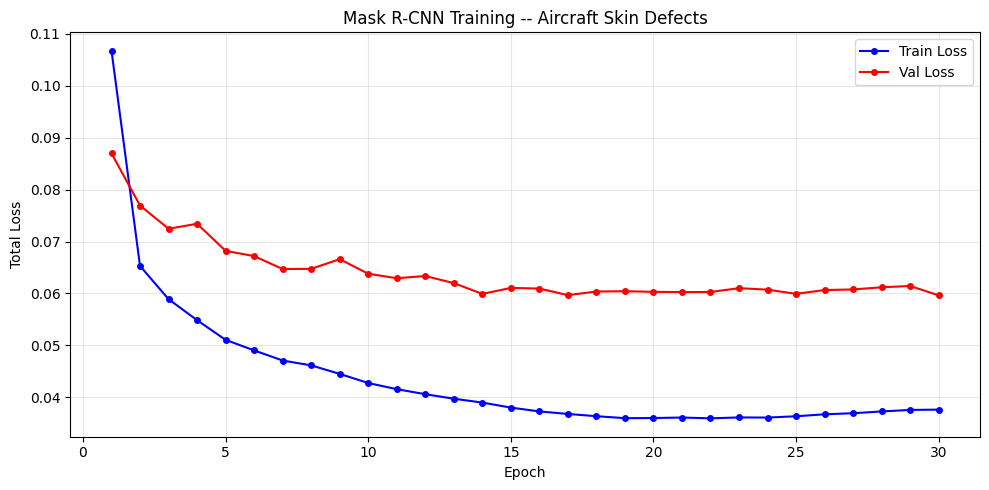

Saved: runs/maskrcnn/training_curves.png


In [15]:
ep = range(1, len(history["train_loss"]) + 1)
 
plt.figure(figsize=(10, 5))
plt.plot(ep, history["train_loss"], "b-o", ms=4, label="Train Loss")
plt.plot(ep, history["val_loss"],   "r-o", ms=4, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Mask R-CNN Training -- Aircraft Skin Defects")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/training_curves.png", dpi=150)
plt.show()
print("Saved:", f"{SAVE_DIR}/training_curves.png")

In [16]:
ckpt = torch.load(f"{SAVE_DIR}/best_model.pth", map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Loaded best model from epoch {ckpt['epoch']}  "
      f"(val_loss={ckpt['val_loss']:.4f})")
 

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Loaded best model from epoch 30  (val_loss=0.0596)


In [21]:

import os

NUM_WORKERS = 0  # Windows fix

test_loader = DataLoader(
    test_ds, batch_size=1, shuffle=False,
    num_workers=0, collate_fn=collate_fn,
)

print("test_loader recreated with num_workers=0")

test_loader recreated with num_workers=0


In [22]:
from pycocotools.coco     import COCO
from pycocotools.cocoeval import COCOeval
 
coco_gt      = COCO(os.path.join(DATA_DIR, "test", "_annotations.coco.json"))
coco_results = []
 
model.eval()
with torch.no_grad():
    for images, targets in test_loader:
        images  = [img.to(DEVICE) for img in images]
        outputs = model(images)
 
        for target, out in zip(targets, outputs):
            img_id = target["image_id"].item()
            for box, score, label in zip(
                out["boxes"].cpu().numpy(),
                out["scores"].cpu().numpy(),
                out["labels"].cpu().numpy(),
            ):
                if score < 0.05:
                    continue
                x1, y1, x2, y2 = box
                cat_id = coco_gt.getCatIds()[label - 1]
                coco_results.append({
                    "image_id":    img_id,
                    "category_id": int(cat_id),
                    "bbox":        [float(x1), float(y1),
                                    float(x2 - x1), float(y2 - y1)],
                    "score":       float(score),
                })
 
if len(coco_results) == 0:
    print("No predictions above threshold -- try lowering conf threshold")
else:
    res_path = f"{SAVE_DIR}/coco_results.json"
    with open(res_path, "w") as f:
        json.dump(coco_results, f)
 
    coco_dt   = coco_gt.loadRes(res_path)
    coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
 
    print("\n-- COCO mAP Results ---------------------------")
    print(f"mAP@50:95  : {coco_eval.stats[0]:.4f}")
    print(f"mAP@50     : {coco_eval.stats[1]:.4f}")
    print(f"mAP@75     : {coco_eval.stats[2]:.4f}")

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.01s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.835
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.852
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.852
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.835
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.850
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.850
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


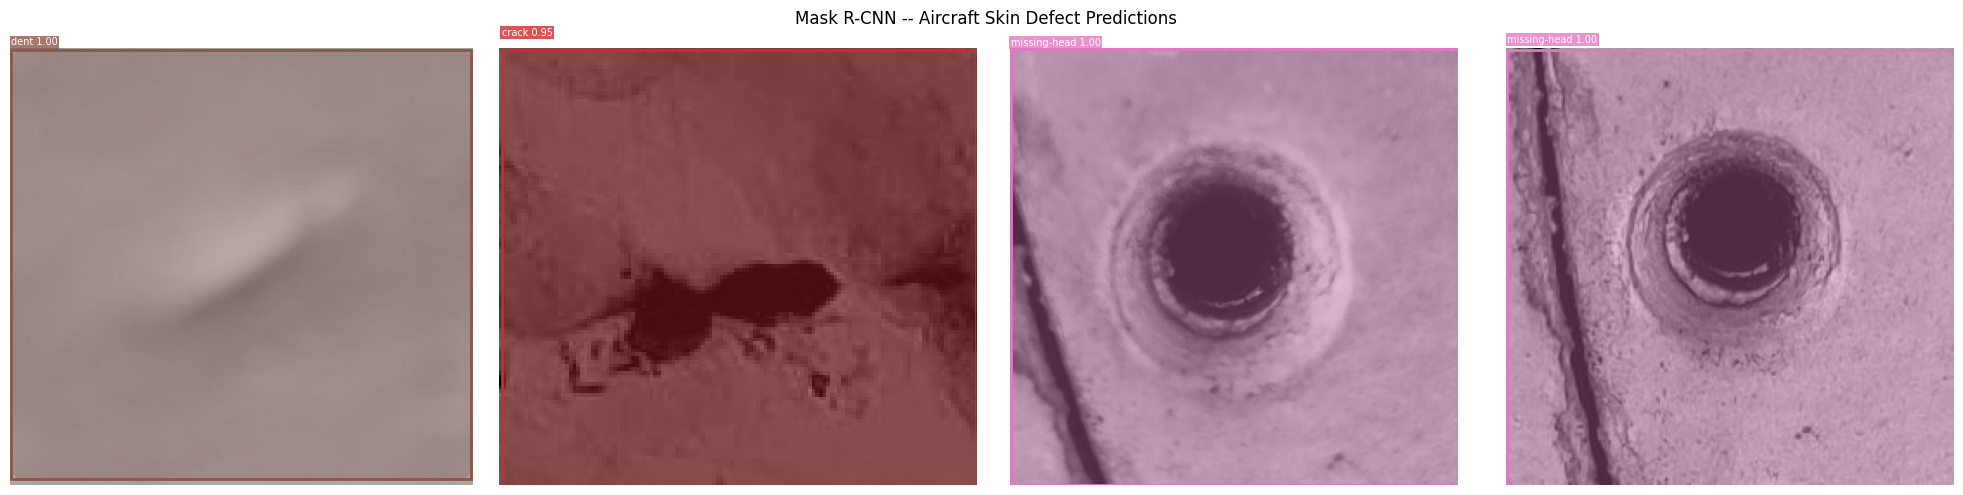

Saved: runs/maskrcnn/predictions_sample.png


In [23]:
CLASS_NAMES = train_ds.class_names
COLORS      = plt.cm.get_cmap("tab10", len(CLASS_NAMES)).colors
CONF_THRESH = 0.50
 
sample_idx = random.sample(range(len(test_ds)), min(4, len(test_ds)))
fig, axes  = plt.subplots(1, len(sample_idx), figsize=(5 * len(sample_idx), 5))
if len(sample_idx) == 1:
    axes = [axes]
 
model.eval()
with torch.no_grad():
    for ax, idx in zip(axes, sample_idx):
        img_t, tgt = test_ds[idx]
        out        = model([img_t.to(DEVICE)])[0]
 
        ax.imshow(img_t.permute(1, 2, 0).numpy(), cmap="gray")
        ax.axis("off")
 
        for box, lbl, score, mask in zip(
            out["boxes"].cpu(),
            out["labels"].cpu(),
            out["scores"].cpu(),
            out["masks"].cpu(),
        ):
            if score < CONF_THRESH:
                continue
 
            x1, y1, x2, y2 = box.numpy()
            c    = COLORS[lbl.item() % len(COLORS)]
            name = CLASS_NAMES[lbl.item()] if lbl.item() < len(CLASS_NAMES) else f"cls{lbl}"
 
            # bounding box
            rect = mpatches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor=c, facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 4, f"{name} {score:.2f}",
                    fontsize=7, color="white",
                    bbox=dict(facecolor=c, alpha=0.8, pad=1, edgecolor="none"))
 
            # mask overlay
            m  = mask[0].numpy()
            ov = np.zeros((*m.shape, 4))
            ov[m > 0.5] = [*c[:3], 0.35]
            ax.imshow(ov)
 
plt.suptitle("Mask R-CNN -- Aircraft Skin Defect Predictions", fontsize=12)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/predictions_sample.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", f"{SAVE_DIR}/predictions_sample.png")

In [24]:
with open(f"{SAVE_DIR}/class_names.json", "w") as f:
    json.dump(train_ds.class_names, f, indent=2)
print("Class names saved.")
 
# TorchScript export (for production deployment)
try:
    scripted = torch.jit.script(model)
    scripted.save(f"{SAVE_DIR}/maskrcnn_aircraft.torchscript")
    print("TorchScript model saved.")
except Exception as e:
    print(f"TorchScript export skipped ({e})")


Class names saved.
TorchScript model saved.


In [26]:
%pip install seaborn

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ------------- -------------------------- 3.9/11.3 MB 23.5 MB/s eta 0:00:01
   ------------------------------------ --- 10.2/11.3 MB 26.6 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 26.3 MB/s  0:00:00

   ---------------------------------------- 0/4 [pytz]
   ---------- ----------------------------- 1/4 [tzdata]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -----------

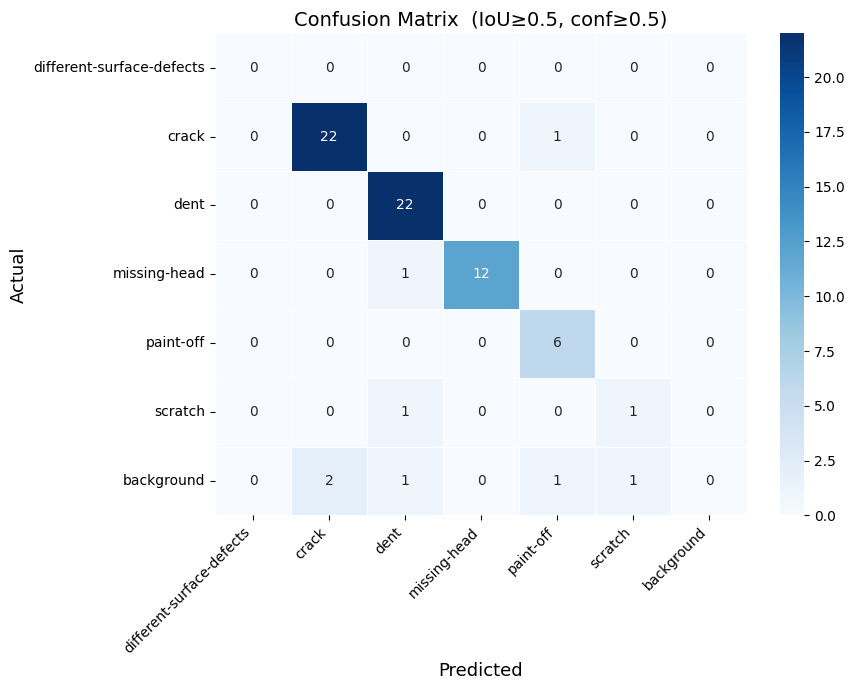

Saved → runs/maskrcnn/confusion_matrix.png

Class                    TP     FP     FN     Prec   Recall
----------------------------------------------------------
different-surface-defects      0      0      0    0.000    0.000
crack                    22      2      0    0.917    1.000
dent                     22      1      0    0.957    1.000
missing-head             12      0      0    1.000    1.000
paint-off                 6      1      0    0.857    1.000
scratch                   1      1      0    0.500    1.000


In [27]:
# ── Confusion Matrix for Mask R-CNN ──────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision.ops import box_iou

IOU_THRESH  = 0.5
CONF_THRESH = 0.5
CLASS_NAMES = train_ds.class_names[1:]   # exclude background
NUM_CLS     = len(CLASS_NAMES)

# Matrix rows = actual, cols = predicted
# Extra row/col for background (FP / FN)
matrix = np.zeros((NUM_CLS + 1, NUM_CLS + 1), dtype=int)
# index NUM_CLS = "background / no detection"

model.eval()
with torch.no_grad():
    for images, targets in test_loader:
        images  = [img.to(DEVICE) for img in images]
        outputs = model(images)

        for target, out in zip(targets, outputs):
            gt_boxes  = target["boxes"].to(DEVICE)
            gt_labels = target["labels"].to(DEVICE)   # 1-based

            # filter predictions by confidence
            keep      = out["scores"] >= CONF_THRESH
            pd_boxes  = out["boxes"][keep]
            pd_labels = out["labels"][keep]   # 1-based

            matched_gt = set()

            for pd_box, pd_lbl in zip(pd_boxes, pd_labels):
                pd_lbl_idx = pd_lbl.item() - 1   # convert to 0-based

                if len(gt_boxes) == 0:
                    # false positive — predicted something, nothing in GT
                    matrix[NUM_CLS][pd_lbl_idx] += 1
                    continue

                # IoU between this prediction and all GT boxes
                ious = box_iou(pd_box.unsqueeze(0), gt_boxes)[0]
                best_iou, best_idx = ious.max(0)

                if best_iou >= IOU_THRESH and best_idx.item() not in matched_gt:
                    gt_lbl_idx = gt_labels[best_idx].item() - 1   # 0-based
                    matrix[gt_lbl_idx][pd_lbl_idx] += 1
                    matched_gt.add(best_idx.item())
                else:
                    # false positive
                    matrix[NUM_CLS][pd_lbl_idx] += 1

            # unmatched GT boxes = false negatives
            for i, gt_lbl in enumerate(gt_labels):
                if i not in matched_gt:
                    gt_lbl_idx = gt_lbl.item() - 1
                    matrix[gt_lbl_idx][NUM_CLS] += 1

# ── Plot ──────────────────────────────────────────────────────
tick_labels = CLASS_NAMES + ["background"]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    matrix,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=tick_labels,
    yticklabels=tick_labels,
    ax=ax,
    linewidths=0.5,
)
ax.set_xlabel("Predicted",  fontsize=13)
ax.set_ylabel("Actual",     fontsize=13)
ax.set_title(f"Confusion Matrix  (IoU≥{IOU_THRESH}, conf≥{CONF_THRESH})", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("runs/maskrcnn/confusion_matrix.png", dpi=150)
plt.show()
print("Saved → runs/maskrcnn/confusion_matrix.png")

# ── Per-class precision / recall from the matrix ─────────────
print(f"\n{'Class':<20} {'TP':>6} {'FP':>6} {'FN':>6} {'Prec':>8} {'Recall':>8}")
print("-" * 58)
for i, name in enumerate(CLASS_NAMES):
    TP = matrix[i, i]
    FP = matrix[NUM_CLS, i]          # background row, predicted as class i
    FN = matrix[i, NUM_CLS]          # actual class i, predicted as background
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    print(f"{name:<20} {TP:>6} {FP:>6} {FN:>6} {precision:>8.3f} {recall:>8.3f}")